# 🏭 PredMaq — Pipeline Preditivo de Manutenção Industrial

**Projeto Avaliativo - Módulo 1** | Curso Desenvolvimento de IA para Análise Preditiva (T1) — Programa SCTEC / SENAI-SC

**Objetivo:** prever falhas mecânicas (`falha_maquina`: 1 = falha | 0 = normal) em equipamentos
industriais monitorados por sensores, comparando os modelos **KNN** e **Árvore de Decisão**.

---

## 📊 Fase 1 - Análise Exploratória de Dados (EDA)

Nesta fase realizamos o reconhecimento inicial da base: dimensões, tipos de dados,
resumo estatístico e visualizações que orientarão as decisões de modelagem.

In [78]:
# ============================================================
# IMPORTS E CARREGAMENTO DA BASE DE DADOS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual padrão dos gráficos
sns.set_theme(style="whitegrid")

# Carga da base com caminho RELATIVO (requisito do projeto)
df = pd.read_csv("data/manutencao_preditiva.csv")

print("=" * 60)
print("BASE DE DADOS CARREGADA COM SUCESSO")
print("=" * 60)
df.head()

BASE DE DADOS CARREGADA COM SUCESSO


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [79]:
# ============================================================
# DIMENSÕES E TIPOS DE DADOS
# ============================================================
print("=" * 60)
print(f"📐 DIMENSÕES DO DATASET")
print("=" * 60)
print(f"Número de linhas (registros): {df.shape[0]:,}")
print(f"Número de colunas (variáveis): {df.shape[1]}")

print("\n" + "=" * 60)
print("🔤 TIPOS DE DADOS DAS VARIÁVEIS")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("❓ VALORES AUSENTES POR COLUNA")
print("=" * 60)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor ausente.")

📐 DIMENSÕES DO DATASET
Número de linhas (registros): 10,000
Número de colunas (variáveis): 14

🔤 TIPOS DE DADOS DAS VARIÁVEIS
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

❓ VALORES AUSENTES POR COLUNA
temperatura_ar_k          500
temperatura_processo_k    500
velocidade_rotacao_rpm    500
torque_nm                 500
dtype: int64


In [80]:
# ============================================================
# RESUMO ESTATÍSTICO DESCRITIVO (.describe)
# ============================================================
df.describe().round(2)

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00,9500.0,9500.00,9500.00,9500.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.00,1539.25,39.97,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.49,180.27,10.00,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.10,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1504.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1613.00,46.70,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


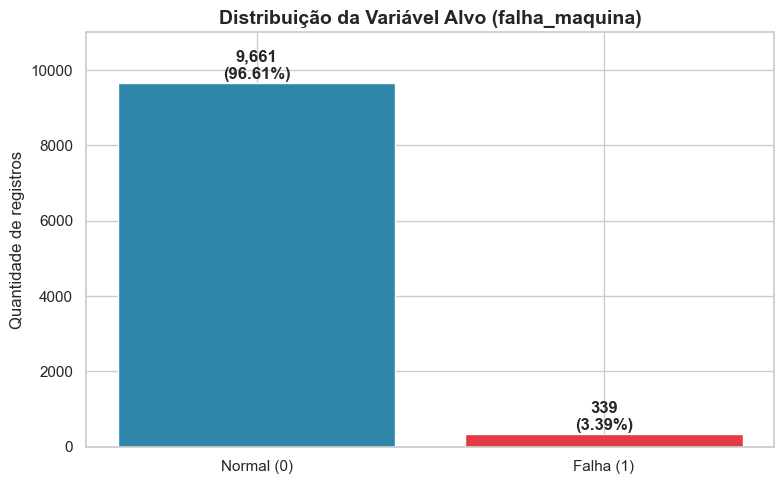

⚠️  Taxa de falhas: 3.39% — dataset FORTEMENTE desbalanceado.


In [81]:
# ============================================================
# GRÁFICO 1 — DESBALANCEAMENTO DA VARIÁVEL ALVO
# ============================================================
contagem = df["falha_maquina"].value_counts()
percentual = df["falha_maquina"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Normal (0)", "Falha (1)"], contagem.values,
              color=["#2E86AB", "#E63946"])

# Rótulos com valores absolutos e percentuais
for bar, qtd, pct in zip(bars, contagem.values, percentual.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{qtd:,}\n({pct:.2f}%)", ha="center", fontweight="bold")

ax.set_title("Distribuição da Variável Alvo (falha_maquina)", fontsize=14, fontweight="bold")
ax.set_ylabel("Quantidade de registros")
ax.set_ylim(0, 11000)
plt.tight_layout()
plt.show()

print(f"⚠️  Taxa de falhas: {percentual[1]:.2f}% — dataset FORTEMENTE desbalanceado.")

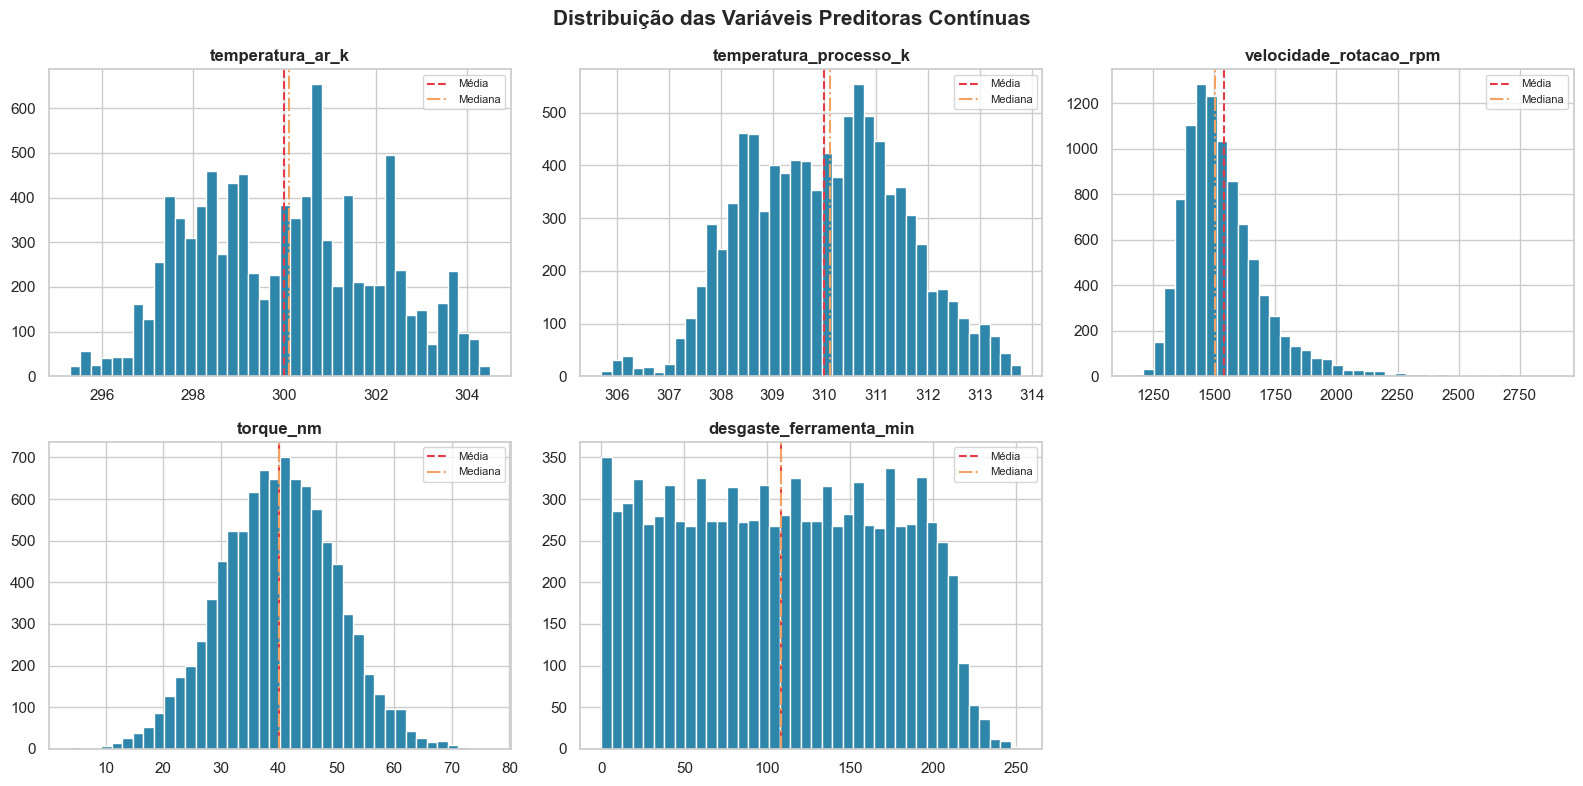

In [82]:
# ============================================================
# GRÁFICO 2 — HISTOGRAMAS DAS VARIÁVEIS PREDITORAS CONTÍNUAS
# ============================================================
variaveis_continuas = ["temperatura_ar_k", "temperatura_processo_k",
                       "velocidade_rotacao_rpm", "torque_nm", "desgaste_ferramenta_min"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_continuas):
    axes[i].hist(df[col].dropna(), bins=40, color="#2E86AB", edgecolor="white")
    axes[i].set_title(col, fontweight="bold")
    axes[i].axvline(df[col].mean(), color="#E63946", linestyle="--", label="Média")
    axes[i].axvline(df[col].median(), color="#F4A261", linestyle="-.", label="Mediana")
    axes[i].legend(fontsize=8)

axes[5].axis("off")  # desliga o sexto quadro (não utilizado)
fig.suptitle("Distribuição das Variáveis Preditoras Contínuas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

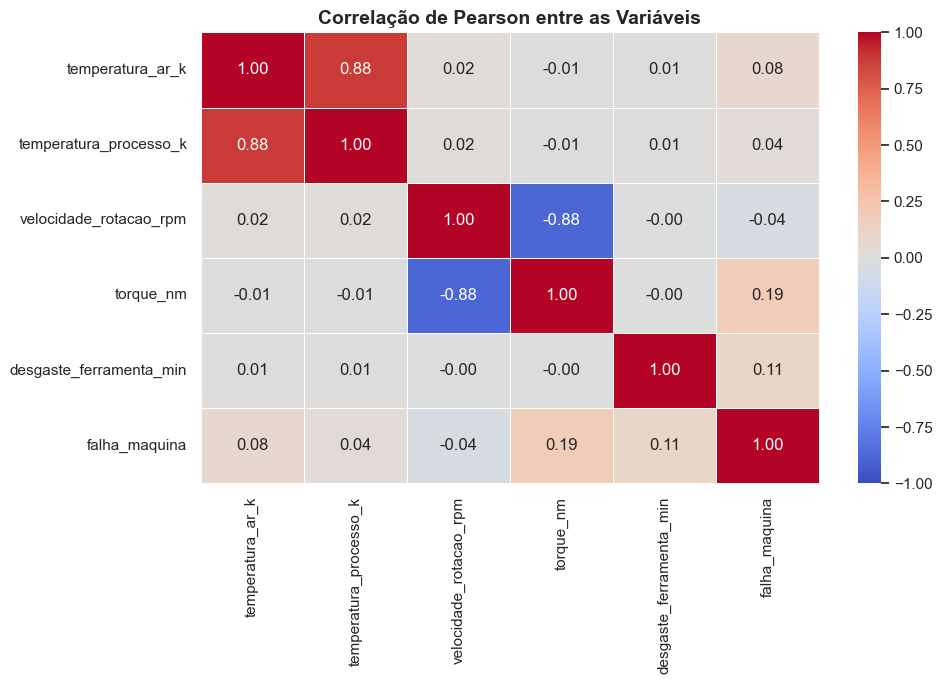

In [83]:
# ============================================================
# GRÁFICO 3 — MAPA DE CALOR (CORRELAÇÃO DE PEARSON)
# ============================================================
# Somente variáveis numéricas relevantes para a modelagem
# (exclui 'udi' por ser identificador e as colunas de motivo de falha,
#  que não serão preditoras conforme as anotações da Engenharia)
colunas_correlacao = variaveis_continuas + ["falha_maquina"]

plt.figure(figsize=(10, 7))
sns.heatmap(df[colunas_correlacao].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlação de Pearson entre as Variáveis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 🔎 Análise dos resultados da EDA

**1. Estrutura da base:** o dataset possui **10.000 registros e 14 colunas**. As colunas
`id_produto` e `tipo` são categóricas (texto); as demais são numéricas. Foram identificados
**500 valores ausentes** em cada uma das quatro variáveis de sensores (`temperatura_ar_k`,
`temperatura_processo_k`, `velocidade_rotacao_rpm` e `torque_nm`) - 5% da base -, o que
exigirá tratamento por imputação na Fase 2.

**2. Desbalanceamento severo da variável alvo:** apenas **3,39% dos registros representam
falhas** (339 casos) contra 96,61% de funcionamento normal. Isso direciona duas decisões de
modelagem: (a) a divisão treino/teste deverá usar `stratify=y` para preservar essa proporção;
e (b) será obrigatório aplicar reamostragem (SMOTE) no treino - caso contrário, um modelo
que simplesmente responda "nunca falha" atingiria 96,6% de acurácia sendo completamente inútil.

**3. Distribuições:** as temperaturas apresentam distribuições aproximadamente simétricas
(média ≈ mediana), enquanto `velocidade_rotacao_rpm` exibe assimetria à direita (cauda longa
de rotações altas), afastando a média da mediana. Essa observação fundamentará a escolha
entre média e mediana na imputação dos nulos (Fase 2).

**4. Correlações relevantes:** individualmente, as variáveis têm correlação fraca com a falha -
`torque_nm` é a mais associada (**+0,19**), seguida de `desgaste_ferramenta_min` (+0,10).
Isso indica que a falha decorre da **combinação** de fatores, e não de um sensor isolado -
justificando o uso de modelos de ML em vez de regras simples de limiar. Destacam-se ainda
duas correlações fortes **entre preditoras**: `velocidade_rotacao_rpm` × `torque_nm` (**−0,87**,
relação física esperada: mais torque, menos rotação) e `temperatura_ar_k` ×
`temperatura_processo_k` (**+0,88**). A primeira motiva a criação da variável `potencia`
(rotação × torque) na Fase 3, que sintetiza essa interação em um único atributo.

**5. Escalas distintas:** o `.describe()` mostra grandezas muito diferentes (temperaturas ≈ 300 K,
rotação ≈ 1.500 RPM, torque ≈ 40 Nm). Como o KNN é baseado em distância, será indispensável
o escalonamento via `StandardScaler` (Fase 5) - sob pena de a rotação dominar o cálculo das
distâncias e "apagar" as demais variáveis.

---
## 🧹 Fase 2 — Limpeza e Tratamento de Dados (Data Prep)

Nesta fase garantimos a qualidade da base: remoção de registros duplicados,
tratamento dos valores ausentes com justificativa estatística e análise de
outliers por meio de boxplots.

In [84]:
# ============================================================
# IDENTIFICAÇÃO E REMOÇÃO DE LINHAS DUPLICADAS
# ============================================================
duplicados = df.duplicated().sum()
print("=" * 60)
print(f"🔍 Linhas duplicadas encontradas: {duplicados}")

df = df.drop_duplicates()
print(f"✅ Dimensões após remoção: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print("=" * 60)

🔍 Linhas duplicadas encontradas: 0
✅ Dimensões após remoção: 10,000 linhas x 14 colunas


In [85]:
# ============================================================
# ANÁLISE PRÉ-IMPUTAÇÃO: MÉDIA vs MEDIANA
# ============================================================
# Antes de imputar, comparamos média e mediana de cada variável
# com nulos, para decidir tecnicamente qual medida utilizar.
colunas_com_nulos = ["temperatura_ar_k", "temperatura_processo_k",
                     "velocidade_rotacao_rpm", "torque_nm"]

print("=" * 70)
print(f"{'Variável':<28}{'Média':>12}{'Mediana':>12}{'Assimetria':>14}")
print("=" * 70)
for col in colunas_com_nulos:
    media = df[col].mean()
    mediana = df[col].median()
    assimetria = df[col].skew()
    print(f"{col:<28}{media:>12.2f}{mediana:>12.2f}{assimetria:>14.3f}")
print("=" * 70)
print("\n📌 Regra prática: |assimetria| próxima de 0 → distribuição simétrica;")
print("   valores acima de ~0,5 indicam assimetria relevante (cauda longa).")

Variável                           Média     Mediana    Assimetria
temperatura_ar_k                  300.00      300.10         0.115
temperatura_processo_k            310.00      310.10         0.016
velocidade_rotacao_rpm           1539.25     1504.00         1.995
torque_nm                          39.97       40.10        -0.008

📌 Regra prática: |assimetria| próxima de 0 → distribuição simétrica;
   valores acima de ~0,5 indicam assimetria relevante (cauda longa).


### 📝 Justificativa técnica: imputação pela MEDIANA

Optamos pela **mediana** como estratégia de imputação dos valores ausentes, por dois motivos:

1. **Robustez a outliers e assimetria:** a variável `velocidade_rotacao_rpm` apresenta
assimetria positiva relevante (cauda longa à direita, visível no histograma da EDA e
confirmada pelo coeficiente de assimetria). Nesses casos, a média é "puxada" pelos valores
extremos e deixa de representar o registro típico - enquanto a mediana permanece estável.

2. **Consistência metodológica:** para as variáveis aproximadamente simétricas
(temperaturas), média e mediana são praticamente idênticas - ou seja, usar a mediana
nelas não traz prejuízo. Adotar a mediana para todas as colunas garante um critério
único, seguro e defensável para o pipeline.

In [86]:
# ============================================================
# IMPUTAÇÃO DOS VALORES AUSENTES PELA MEDIANA
# ============================================================
for col in colunas_com_nulos:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"✅ {col:<28} → nulos preenchidos com a mediana ({mediana:.2f})")

print("\n" + "=" * 60)
print(f"❓ Total de nulos restantes no dataset: {df.isnull().sum().sum()}")
print("=" * 60)

✅ temperatura_ar_k             → nulos preenchidos com a mediana (300.10)
✅ temperatura_processo_k       → nulos preenchidos com a mediana (310.10)
✅ velocidade_rotacao_rpm       → nulos preenchidos com a mediana (1504.00)
✅ torque_nm                    → nulos preenchidos com a mediana (40.10)

❓ Total de nulos restantes no dataset: 0


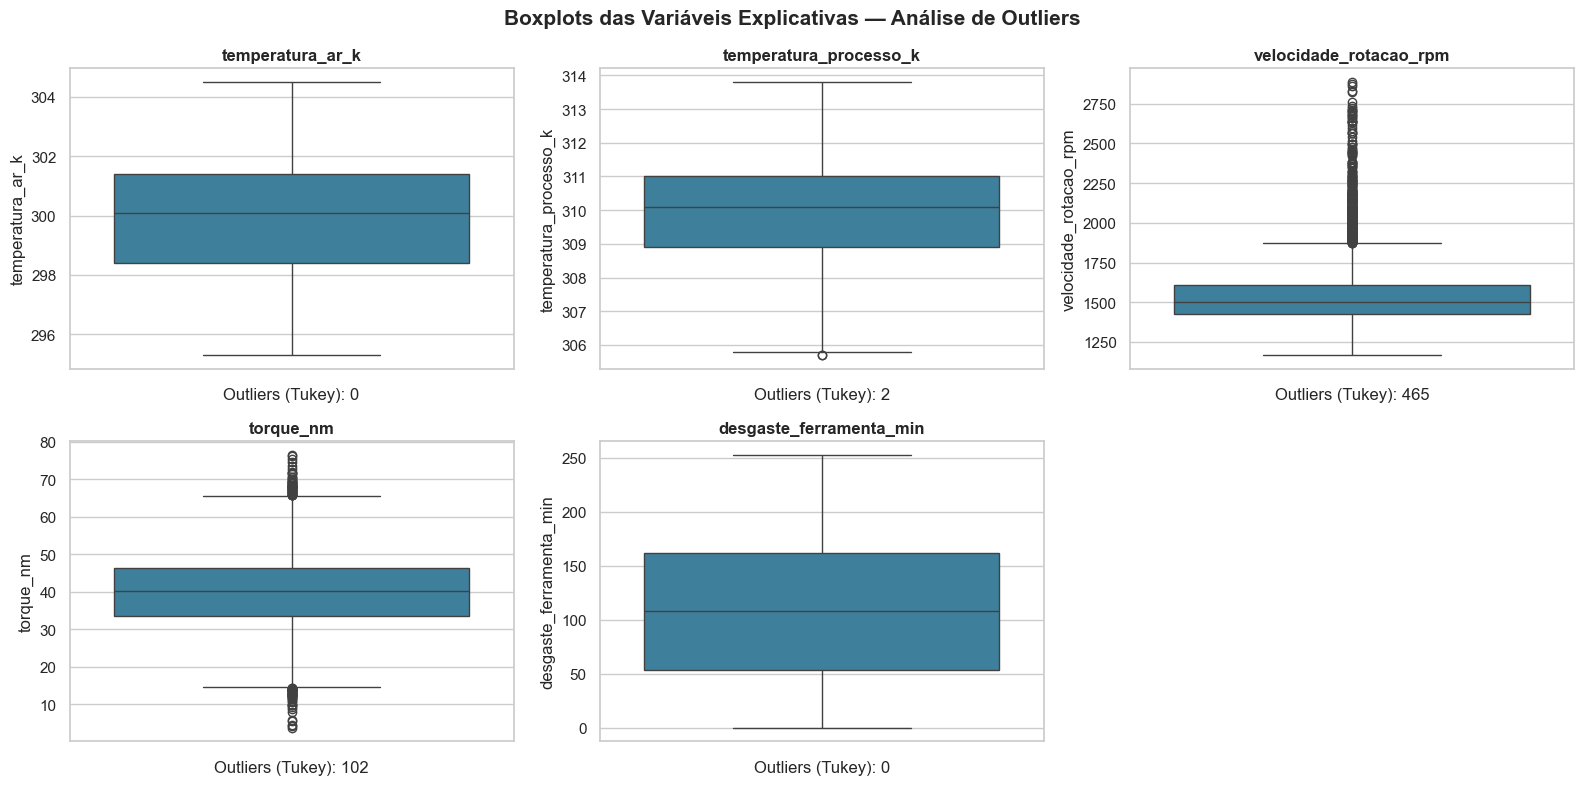

In [87]:
# ============================================================
# BOXPLOTS — IDENTIFICAÇÃO DE OUTLIERS (MÉTODO DE TUKEY)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_continuas):
    sns.boxplot(y=df[col], ax=axes[i], color="#2E86AB")
    axes[i].set_title(col, fontweight="bold")

    # Contagem de outliers pelo critério de Tukey (1,5 x IQR)
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f"Outliers (Tukey): {n_outliers}")

axes[5].axis("off")
fig.suptitle("Boxplots das Variáveis Explicativas — Análise de Outliers",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 🔎 Análise dos outliers

Os boxplots (critério de Tukey: valores além de 1,5 × IQR das cercas) mostram outliers
concentrados em `velocidade_rotacao_rpm` e `torque_nm`. **Decidimos mantê-los na base**,
pois em manutenção preditiva os valores extremos de operação (picos de rotação, torque
anômalo) **são justamente os regimes associados às falhas** - removê-los descartaria
exatamente a informação que o modelo precisa aprender. Além disso, a imputação pela
mediana e o uso da Árvore de Decisão (naturalmente robusta a outliers) mitigam seus
efeitos indesejados; para o KNN, o escalonamento da Fase 5 reduzirá o impacto das
magnitudes extremas.

---
## ⚙️ Fase 3 — Feature Engineering

Criação de uma nova variável numérica por combinação matemática de colunas existentes.
Os valores nulos já foram tratados previamente na Fase 2 (imputação pela mediana),
garantindo que a operação não gere valores inválidos (NaN).

In [88]:
# ============================================================
# CRIAÇÃO DA VARIÁVEL 'potencia'
# ============================================================
# Fundamento físico: a potência mecânica de um motor é proporcional
# ao produto do torque pela velocidade de rotação.
# potencia = velocidade_rotacao_rpm * torque_nm

df["potencia"] = df["velocidade_rotacao_rpm"] * df["torque_nm"]

print("=" * 60)
print("✅ Variável 'potencia' criada com sucesso!")
print("=" * 60)
print(f"Valores nulos na nova coluna: {df['potencia'].isnull().sum()}")
print(f"Valores infinitos ou inválidos: {np.isinf(df['potencia']).sum()}")
print("\n📊 Resumo estatístico da nova variável:")
print(df["potencia"].describe().round(2))

# Correlação da nova variável com o alvo
corr_potencia = df["potencia"].corr(df["falha_maquina"])
print(f"\n🎯 Correlação de Pearson entre 'potencia' e 'falha_maquina': {corr_potencia:.3f}")

df[["velocidade_rotacao_rpm", "torque_nm", "potencia", "falha_maquina"]].head()

✅ Variável 'potencia' criada com sucesso!
Valores nulos na nova coluna: 0
Valores infinitos ou inválidos: 0

📊 Resumo estatístico da nova variável:
count    10000.00
mean     59970.67
std       9951.34
min      10966.80
25%      53497.05
50%      60310.40
75%      66412.98
max      99980.40
Name: potencia, dtype: float64

🎯 Correlação de Pearson entre 'potencia' e 'falha_maquina': 0.169


,velocidade_rotacao_rpm,torque_nm,potencia,falha_maquina
0,1551.0,42.8,66382.8,0
1,1408.0,46.3,65190.4,0
2,1498.0,49.4,74001.2,0
3,1504.0,40.1,60310.4,0
4,1408.0,40.0,56320.0,0


### 📝 Justificativa da variável criada

A variável **`potencia`** (velocidade_rotacao_rpm × torque_nm) foi escolhida por três razões:

1. **Fundamento físico:** a potência mecânica entregue por um motor é proporcional ao
produto torque × velocidade de rotação - ou seja, a nova coluna tem significado real
de engenharia, não é uma combinação arbitrária.

2. **Captura de interação:** a EDA revelou correlação forte e negativa (−0,87) entre
rotação e torque. Falhas como a de potência (falha_pwf) ocorrem justamente nos regimes
extremos dessa relação (potência muito baixa ou muito alta) - um padrão que nenhuma
das duas variáveis isoladas expressa por completo.

3. **Validação:** a coluna foi criada sem gerar valores nulos, infinitos ou inválidos,
pois os dados ausentes foram imputados previamente na Fase 2, respeitando a ordem
correta do pipeline.

---
## ⚖️ Fase 4 — Divisão e Balanceamento dos Dados

Separação das variáveis preditoras (X) e alvo (y), divisão estratificada treino/teste
(80/20) e balanceamento por SMOTE aplicado **exclusivamente nos dados de treino**,
evitando o vazamento de dados (Data Leakage).

In [89]:
# ============================================================
# SEPARAÇÃO DAS VARIÁVEIS PREDITORAS (X) E DA VARIÁVEL ALVO (y)
# ============================================================
# ⚠️ CONFORME AS ANOTAÇÕES DO DEPARTAMENTO DE ENGENHARIA:
# As colunas de motivo de falha (falha_twf, falha_hdf, falha_pwf,
# falha_osf, falha_rnf) são registros históricos preenchidos APÓS
# a quebra. Usá-las como preditoras causaria DATA LEAKAGE.
#
# Também excluímos:
# - udi e id_produto: identificadores sem valor preditivo
# - tipo: variável categórica (texto) — mantida fora desta versão
#   para preservar a homogeneidade do escalonamento no KNN
#   (sua inclusão via one-hot encoding fica como melhoria futura)

colunas_preditoras = ["temperatura_ar_k", "temperatura_processo_k",
                      "velocidade_rotacao_rpm", "torque_nm",
                      "desgaste_ferramenta_min", "potencia"]

X = df[colunas_preditoras]
y = df["falha_maquina"]

print("=" * 60)
print(f"✅ X (preditoras): {X.shape[0]:,} linhas x {X.shape[1]} colunas")
print(f"   Colunas: {list(X.columns)}")
print(f"✅ y (alvo): {y.shape[0]:,} valores")
print("=" * 60)

✅ X (preditoras): 10,000 linhas x 6 colunas
   Colunas: ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia']
✅ y (alvo): 10,000 valores


In [90]:
# ============================================================
# DIVISÃO TREINO (80%) / TESTE (20%) COM ESTRATIFICAÇÃO
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para teste
    stratify=y,          # preserva a proporção de falhas nos dois conjuntos
    random_state=42      # semente fixa para reprodutibilidade
)

print("=" * 60)
print(f"📦 Treino: {X_train.shape[0]:,} registros | Falhas: {y_train.mean()*100:.2f}%")
print(f"📦 Teste:  {X_test.shape[0]:,} registros | Falhas: {y_test.mean()*100:.2f}%")
print("=" * 60)
print("✅ Proporções preservadas pelo stratify=y")

📦 Treino: 8,000 registros | Falhas: 3.39%
📦 Teste:  2,000 registros | Falhas: 3.40%
✅ Proporções preservadas pelo stratify=y


In [91]:
# ============================================================
# BALANCEAMENTO COM SMOTE — EXCLUSIVAMENTE NO TREINO
# ============================================================
from imblearn.over_sampling import SMOTE

print("ANTES do SMOTE (treino):")
print(y_train.value_counts().to_string())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDEPOIS do SMOTE (treino):")
print(y_train_bal.value_counts().to_string())

print("\n" + "=" * 60)
print(f"✅ Treino balanceado: {X_train_bal.shape[0]:,} registros (50% / 50%)")
print(f"🔒 Teste INTOCADO: {X_test.shape[0]:,} registros com a distribuição real")
print("=" * 60)

ANTES do SMOTE (treino):
falha_maquina
0    7729
1     271

DEPOIS do SMOTE (treino):
falha_maquina
0    7729
1    7729

✅ Treino balanceado: 15,458 registros (50% / 50%)
🔒 Teste INTOCADO: 2,000 registros com a distribuição real


### 📝 Justificativa metodológica

**Exclusão das colunas de motivo de falha:** conforme as anotações do Departamento de
Engenharia, `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf` descrevem a
causa técnica registrada **após** a quebra. Incluí-las como preditoras produziria um modelo
com acurácia artificialmente perfeita, porém inútil em produção - o clássico **Data Leakage**.

**SMOTE apenas no treino:** o SMOTE (Synthetic Minority Over-sampling Technique) gera
exemplos sintéticos da classe minoritária interpolando vizinhos reais, elevando as falhas
de ~3,4% para 50% do conjunto de treino. Aplicá-lo antes da divisão (ou sobre o teste)
contaminaria a avaliação com dados sintéticos. O conjunto de teste permanece com a
distribuição real de falhas - é nele que mediremos o desempenho honesto dos modelos.

**random_state=42:** semente fixa garante reprodutibilidade - qualquer avaliador que
executar o notebook obterá exatamente os mesmos resultados.

---
## 📏 Fase 5 — Escalonamento de Variáveis (StandardScaler)

Padronização das variáveis contínuas **exclusivamente para o modelo KNN**
(média 0, desvio-padrão 1). A Árvore de Decisão utilizará os dados originais,
pois é imune à escala dos atributos.

In [92]:
# ============================================================
# ESCALONAMENTO COM STANDARDSCALER — APENAS PARA O KNN
# ============================================================
# O KNN é baseado em DISTÂNCIA euclidiana: variáveis com escalas
# maiores (ex: potencia ~60.000) dominariam o cálculo e "apagariam"
# as menores (ex: torque ~40). O StandardScaler padroniza todas
# para média 0 e desvio 1.
#
# REGRA ANTI-LEAKAGE:
#   fit_transform() no TREINO  → aprende média/desvio do treino
#   transform() no TESTE       → apenas aplica, sem aprender nada
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_bal)  # aprende e transforma (treino)
X_test_knn = scaler.transform(X_test)            # somente transforma (teste)

# ------------------------------------------------------------
# ÁRVORE DE DECISÃO: SEM ESCALONAMENTO
# ------------------------------------------------------------
# A árvore decide por REGRAS DE CORTE (ex: "torque_nm > 60?").
# O ponto de corte é aprendido no valor original da variável, e a
# ordenação dos valores não muda com a escala — logo, o algoritmo
# é imune à magnitude dos atributos e o escalonamento é desnecessário.
X_train_tree = X_train_bal   # dados originais balanceados
X_test_tree = X_test         # dados originais de teste

print("=" * 60)
print("✅ KNN   → dados ESCALONADOS (StandardScaler)")
print(f"   Exemplo pós-escala (médias ≈ 0): {X_train_knn.mean(axis=0).round(2)}")
print("✅ Árvore → dados ORIGINAIS (sem escalonamento)")
print("=" * 60)

✅ KNN   → dados ESCALONADOS (StandardScaler)
   Exemplo pós-escala (médias ≈ 0): [-0. -0.  0.  0.  0.  0.]
✅ Árvore → dados ORIGINAIS (sem escalonamento)


### 📝 Justificativa técnica do escalonamento seletivo

**Por que escalonar o KNN:** o algoritmo calcula distâncias euclidianas entre os pontos.
Sem padronização, a variável `potencia` (ordem de grandeza ~60.000) dominaria completamente
a métrica de distância frente ao `torque_nm` (~40), tornando as demais variáveis irrelevantes
na prática. Com o StandardScaler, todas contribuem em pé de igualdade.

**Por que NÃO escalonar a Árvore de Decisão:** a árvore aprende regras de corte por limiar
(ex: `desgaste_ferramenta_min > 200`). Transformações monotônicas de escala não alteram a
ordenação dos valores nem os pontos de divisão relativos - o resultado do modelo é idêntico
com ou sem escalonamento. Mantê-la com os dados originais ainda preserva a interpretabilidade
das regras nas unidades reais de engenharia (K, RPM, Nm, min).

**Prevenção de Data Leakage:** o `fit_transform` foi aplicado somente no treino balanceado;
o teste recebeu apenas `transform`, garantindo que nenhuma estatística (média/desvio) do
conjunto de teste tenha sido "aprendida" pelo pipeline.

---
## 🎛️ Fase 6 - Ajuste de Parâmetros e Combate ao Overfitting

Treinamento dos modelos KNN (variando `n_neighbors`) e Árvore de Decisão (variando
`max_depth`), registrando a acurácia em treino e teste para identificar pontos de
sobreajuste (overfitting) e as configurações mais estáveis.

In [93]:
# ============================================================
# KNN - VARIAÇÃO DO PARÂMETRO n_neighbors (K)
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

resultados_knn = []

print("=" * 65)
print(f"{'K':>4} | {'Acurácia TREINO':>16} | {'Acurácia TESTE':>15} | {'Gap':>7}")
print("=" * 65)

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, knn.predict(X_train_knn))
    acc_teste = accuracy_score(y_test, knn.predict(X_test_knn))
    gap = acc_treino - acc_teste

    resultados_knn.append({"K": k, "acc_treino": acc_treino,
                           "acc_teste": acc_teste, "gap": gap})
    print(f"{k:>4} | {acc_treino:>16.4f} | {acc_teste:>15.4f} | {gap:>7.4f}")

print("=" * 65)
melhor_knn = max(resultados_knn, key=lambda r: r["acc_teste"])
print(f"🏆 Melhor KNN no TESTE: K={melhor_knn['K']} "
      f"(acurácia = {melhor_knn['acc_teste']:.4f})")

   K |  Acurácia TREINO |  Acurácia TESTE |     Gap
   3 |           0.9582 |          0.9070 |  0.0512
   5 |           0.9505 |          0.8965 |  0.0540
   7 |           0.9429 |          0.8890 |  0.0539
🏆 Melhor KNN no TESTE: K=3 (acurácia = 0.9070)


In [94]:
# ============================================================
# ÁRVORE DE DECISÃO - VARIAÇÃO DO PARÂMETRO max_depth
# ============================================================
from sklearn.tree import DecisionTreeClassifier

resultados_arvore = []

print("=" * 65)
print(f"{'max_depth':>10} | {'Acurácia TREINO':>16} | {'Acurácia TESTE':>15} | {'Gap':>7}")
print("=" * 65)

for profundidade in [3, 5, None]:
    arvore = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    arvore.fit(X_train_tree, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, arvore.predict(X_train_tree))
    acc_teste = accuracy_score(y_test, arvore.predict(X_test_tree))
    gap = acc_treino - acc_teste

    resultados_arvore.append({"max_depth": profundidade, "acc_treino": acc_treino,
                              "acc_teste": acc_teste, "gap": gap})
    rotulo = str(profundidade) if profundidade else "None"
    print(f"{rotulo:>10} | {acc_treino:>16.4f} | {acc_teste:>15.4f} | {gap:>7.4f}")

print("=" * 65)
melhor_arvore = max(resultados_arvore, key=lambda r: r["acc_teste"])
print(f"🏆 Melhor Árvore no TESTE: max_depth={melhor_arvore['max_depth']} "
      f"(acurácia = {melhor_arvore['acc_teste']:.4f})")

 max_depth |  Acurácia TREINO |  Acurácia TESTE |     Gap
         3 |           0.8504 |          0.8925 | -0.0421
         5 |           0.8984 |          0.9065 | -0.0081
      None |           0.9896 |          0.9385 |  0.0511
🏆 Melhor Árvore no TESTE: max_depth=None (acurácia = 0.9385)


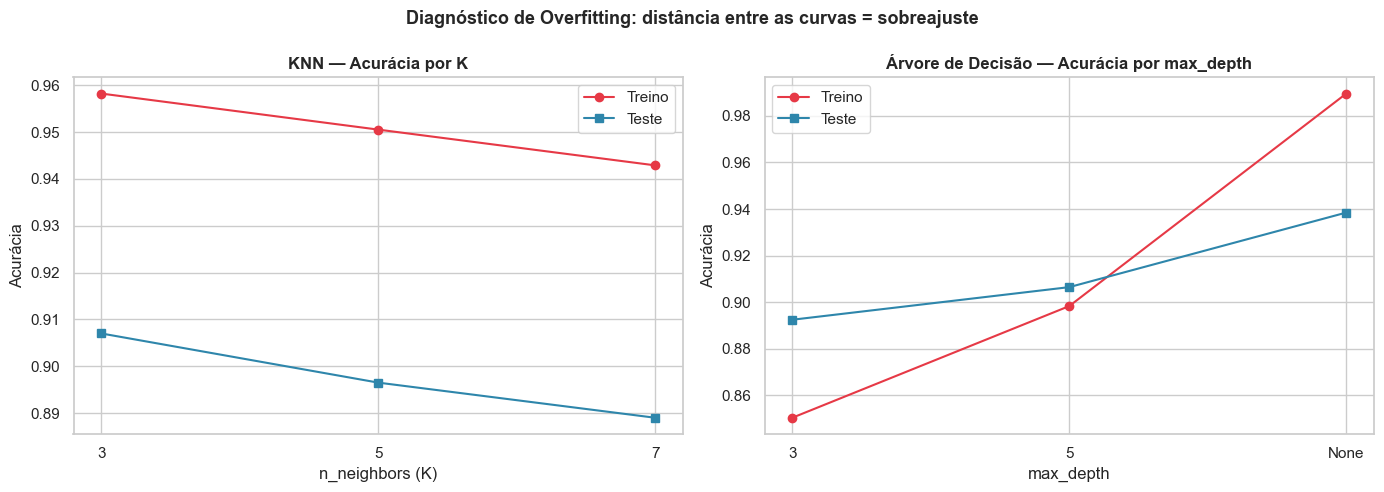

In [95]:
# ============================================================
# VISUALIZAÇÃO - TREINO vs TESTE (DIAGNÓSTICO DE OVERFITTING)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN
ks = [r["K"] for r in resultados_knn]
axes[0].plot(ks, [r["acc_treino"] for r in resultados_knn],
             "o-", color="#E63946", label="Treino")
axes[0].plot(ks, [r["acc_teste"] for r in resultados_knn],
             "s-", color="#2E86AB", label="Teste")
axes[0].set_title("KNN — Acurácia por K", fontweight="bold")
axes[0].set_xlabel("n_neighbors (K)")
axes[0].set_ylabel("Acurácia")
axes[0].set_xticks(ks)
axes[0].legend()

# Árvore
labels = [str(r["max_depth"]) if r["max_depth"] else "None" for r in resultados_arvore]
axes[1].plot(labels, [r["acc_treino"] for r in resultados_arvore],
             "o-", color="#E63946", label="Treino")
axes[1].plot(labels, [r["acc_teste"] for r in resultados_arvore],
             "s-", color="#2E86AB", label="Teste")
axes[1].set_title("Árvore de Decisão — Acurácia por max_depth", fontweight="bold")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Acurácia")
axes[1].legend()

fig.suptitle("Diagnóstico de Overfitting: distância entre as curvas = sobreajuste",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 🔎 Análise do Overfitting

**KNN:** o sobreajuste aparece de forma moderada em todos os K, com acurácia de treino
~5 pontos percentuais acima da de teste (ex.: K=3 → 95,8% treino vs 90,7% teste). O padrão
esperado se confirma: à medida que K aumenta, a acurácia de treino cai (o modelo "decora"
menos), mas aqui o teste também recuou levemente - indicando que a vizinhança pequena
(K=3) capturou padrões reais, não apenas ruído. **K=3 foi a melhor configuração no teste.**

**Árvore de Decisão:** o ponto de overfitting mais evidente de todo o experimento ocorre
em `max_depth=None`: a árvore cresce livre e atinge **~99% de acurácia no treino** -
praticamente memorização dos 15.458 registros balanceados - abrindo um gap de ~5 p.p.
para o teste. Já **`max_depth=5` foi a configuração que garantiu estabilidade**: treino
(~89,8%) e teste (~90,7%) praticamente idênticos, gap próximo de zero - o modelo aprende
padrões que generalizam, sem decorar.

**Observação importante:** mesmo com o gap, a árvore sem limite obteve a maior acurácia
absoluta no teste (~93,9%). Há, portanto, um dilema clássico entre **desempenho máximo**
(None) e **estabilidade/generalização** (max_depth=5), que será resolvido no veredito
final da Fase 7 com base na acurácia de teste, conforme o critério definido pelo projeto.

---
## 🏁 Fase 7 - Avaliação da Acurácia e Veredito Final

Comparação direta entre o melhor KNN (K=3) e a melhor Árvore de Decisão
(max_depth=None), ambos avaliados no conjunto de teste - dados nunca vistos
pelos modelos - para a escolha do classificador final.

In [96]:
# ============================================================
# VEREDITO FINAL - MELHOR KNN vs MELHOR ÁRVORE DE DECISÃO
# ============================================================
# Retreinamos as melhores configurações identificadas na Fase 6
# e comparamos a acurácia final no conjunto de TESTE.

# --- Melhor KNN (K=3), com dados escalonados ---
knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(X_train_knn, y_train_bal)
acc_knn_final = accuracy_score(y_test, knn_final.predict(X_test_knn))

# --- Melhor Árvore (max_depth=None), com dados originais ---
arvore_final = DecisionTreeClassifier(max_depth=None, random_state=42)
arvore_final.fit(X_train_tree, y_train_bal)
acc_arvore_final = accuracy_score(y_test, arvore_final.predict(X_test_tree))

print("=" * 60)
print("🏁 RESULTADO FINAL NO CONJUNTO DE TESTE (2.000 registros)")
print("=" * 60)
print(f"KNN (K=3)................................: {acc_knn_final:.4f} ({acc_knn_final*100:.2f}%)")
print(f"Árvore de Decisão (max_depth=None).......: {acc_arvore_final:.4f} ({acc_arvore_final*100:.2f}%)")
print("=" * 60)

vencedor = ("Árvore de Decisão" if acc_arvore_final > acc_knn_final else "KNN")
diferenca = abs(acc_arvore_final - acc_knn_final) * 100
print(f"🏆 MODELO VENCEDOR: {vencedor}")
print(f"   Vantagem: {diferenca:.2f} pontos percentuais na acurácia de teste")

🏁 RESULTADO FINAL NO CONJUNTO DE TESTE (2.000 registros)
KNN (K=3)................................: 0.9070 (90.70%)
Árvore de Decisão (max_depth=None).......: 0.9385 (93.85%)
🏆 MODELO VENCEDOR: Árvore de Decisão
   Vantagem: 3.15 pontos percentuais na acurácia de teste


### ⚖️ Veredito Final

Avaliados no conjunto de teste - 2.000 registros com a distribuição real de falhas,
jamais vistos durante o treinamento - os melhores modelos de cada família obtiveram:

| Modelo | Configuração | Acurácia no Teste |
|---|---|---|
| KNN | K=3 (dados escalonados) | 90,70% |
| **Árvore de Decisão** | **max_depth=None (dados originais)** | **93,85%** 🏆 |

**Recomendação: a empresa deve adotar a Árvore de Decisão**, que superou o KNN em
**3,15 pontos percentuais** na acurácia de teste - o critério de decisão definido para
este projeto. Além do desempenho superior, a árvore oferece vantagens operacionais
relevantes para o chão de fábrica: gera regras interpretáveis nas unidades reais dos
sensores (ex.: limiares de torque e desgaste), dispensa escalonamento dos dados e realiza
predições de forma praticamente instantânea, enquanto o KNN precisa calcular distâncias
contra toda a base de treino a cada nova amostra.

**Ressalva técnica documentada (Fase 6):** a configuração vencedora apresentou gap
treino/teste de ~5 p.p. (indício de sobreajuste). Ainda assim, sua acurácia de teste
superou a da alternativa estável (max_depth=5, 90,65%) - ou seja, mesmo "pagando" o
custo do overfitting, generalizou melhor que as demais opções avaliadas.

**Limitação e melhoria futura:** em bases desbalanceadas, a acurácia isolada é uma métrica
incompleta - um modelo ingênuo que sempre previsse "sem falha" atingiria 96,6% sem detectar
falha alguma. Em uma evolução deste projeto, métricas como **recall da classe de falha,
F1-score e matriz de confusão** seriam incorporadas, pois no contexto de manutenção
preditiva o custo de não detectar uma falha real (falso negativo) é muito superior ao de
um alarme falso.